<a href="https://colab.research.google.com/github/pedrogebert-jpg/Alimentos_2026/blob/main/Semin%C3%A1rio1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Alimentos - processamento, aditivos e valor energético**


---

Beatriz Thainara, 17881120

Cristina Pan, 17884613

Pedro Musseli, 17919635



---
Fonte do banco de dados: TBCA - tabela brasileira de composição de alimentos.
https://www.tbca.net.br/base-dados/composicao_estatistica.php

Acesso em: 24.08.2026 - 13:02



---




Neste trabalho analisamos alguns alimentos quanto à sua composição, tipo de processamento, presença de aditivos e valor energético.



In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('/content/basededados_seminario1.xlsx')
print(f"The DataFrame has {len(df)} rows (counting from 1).")

The DataFrame has 21 rows (counting from 1).


In [4]:
display(df)

,Alimento,Grupo de alimento,"Nível de processamento (1 menos processado, 4 mais processado)",Valor energético (Kcal) em 100g,Número de aditivos,Valor energético proveniente principalmente de:,Quantidade (g) de gorduras totais em 100g
0,Banana,Frutas e derivados,1,109,0,Carboidratos,0.19
1,Maçã,Frutas e derivados,1,64,0,Carboidratos,0.49
2,Azeite de dendê,Gorduras e óleos,2,900,0,Gorduras totais,100.00
3,Manteiga de garrafa,Leite e derivados,2,889,0,Gorduras totais,98.80
4,Linhaça,Nozes e sementes,1,452,0,Gorduras totais,32.20
5,Gergelim,Nozes e sementes,1,601,0,Gorduras totais,50.40
6,Milho em lata,Vegetais e derivados,3,103,1,Carboidratos,1.83
7,Arroz polido,Cereais e derivados,1,345,0,Carboidratos,0.50
8,Aveia em flocos,Cereais e derivados,1,378,0,Carboidratos,8.60
9,Biscoito cream cracker,Cereais e derivados,4,439,6,Carboidratos,13.80


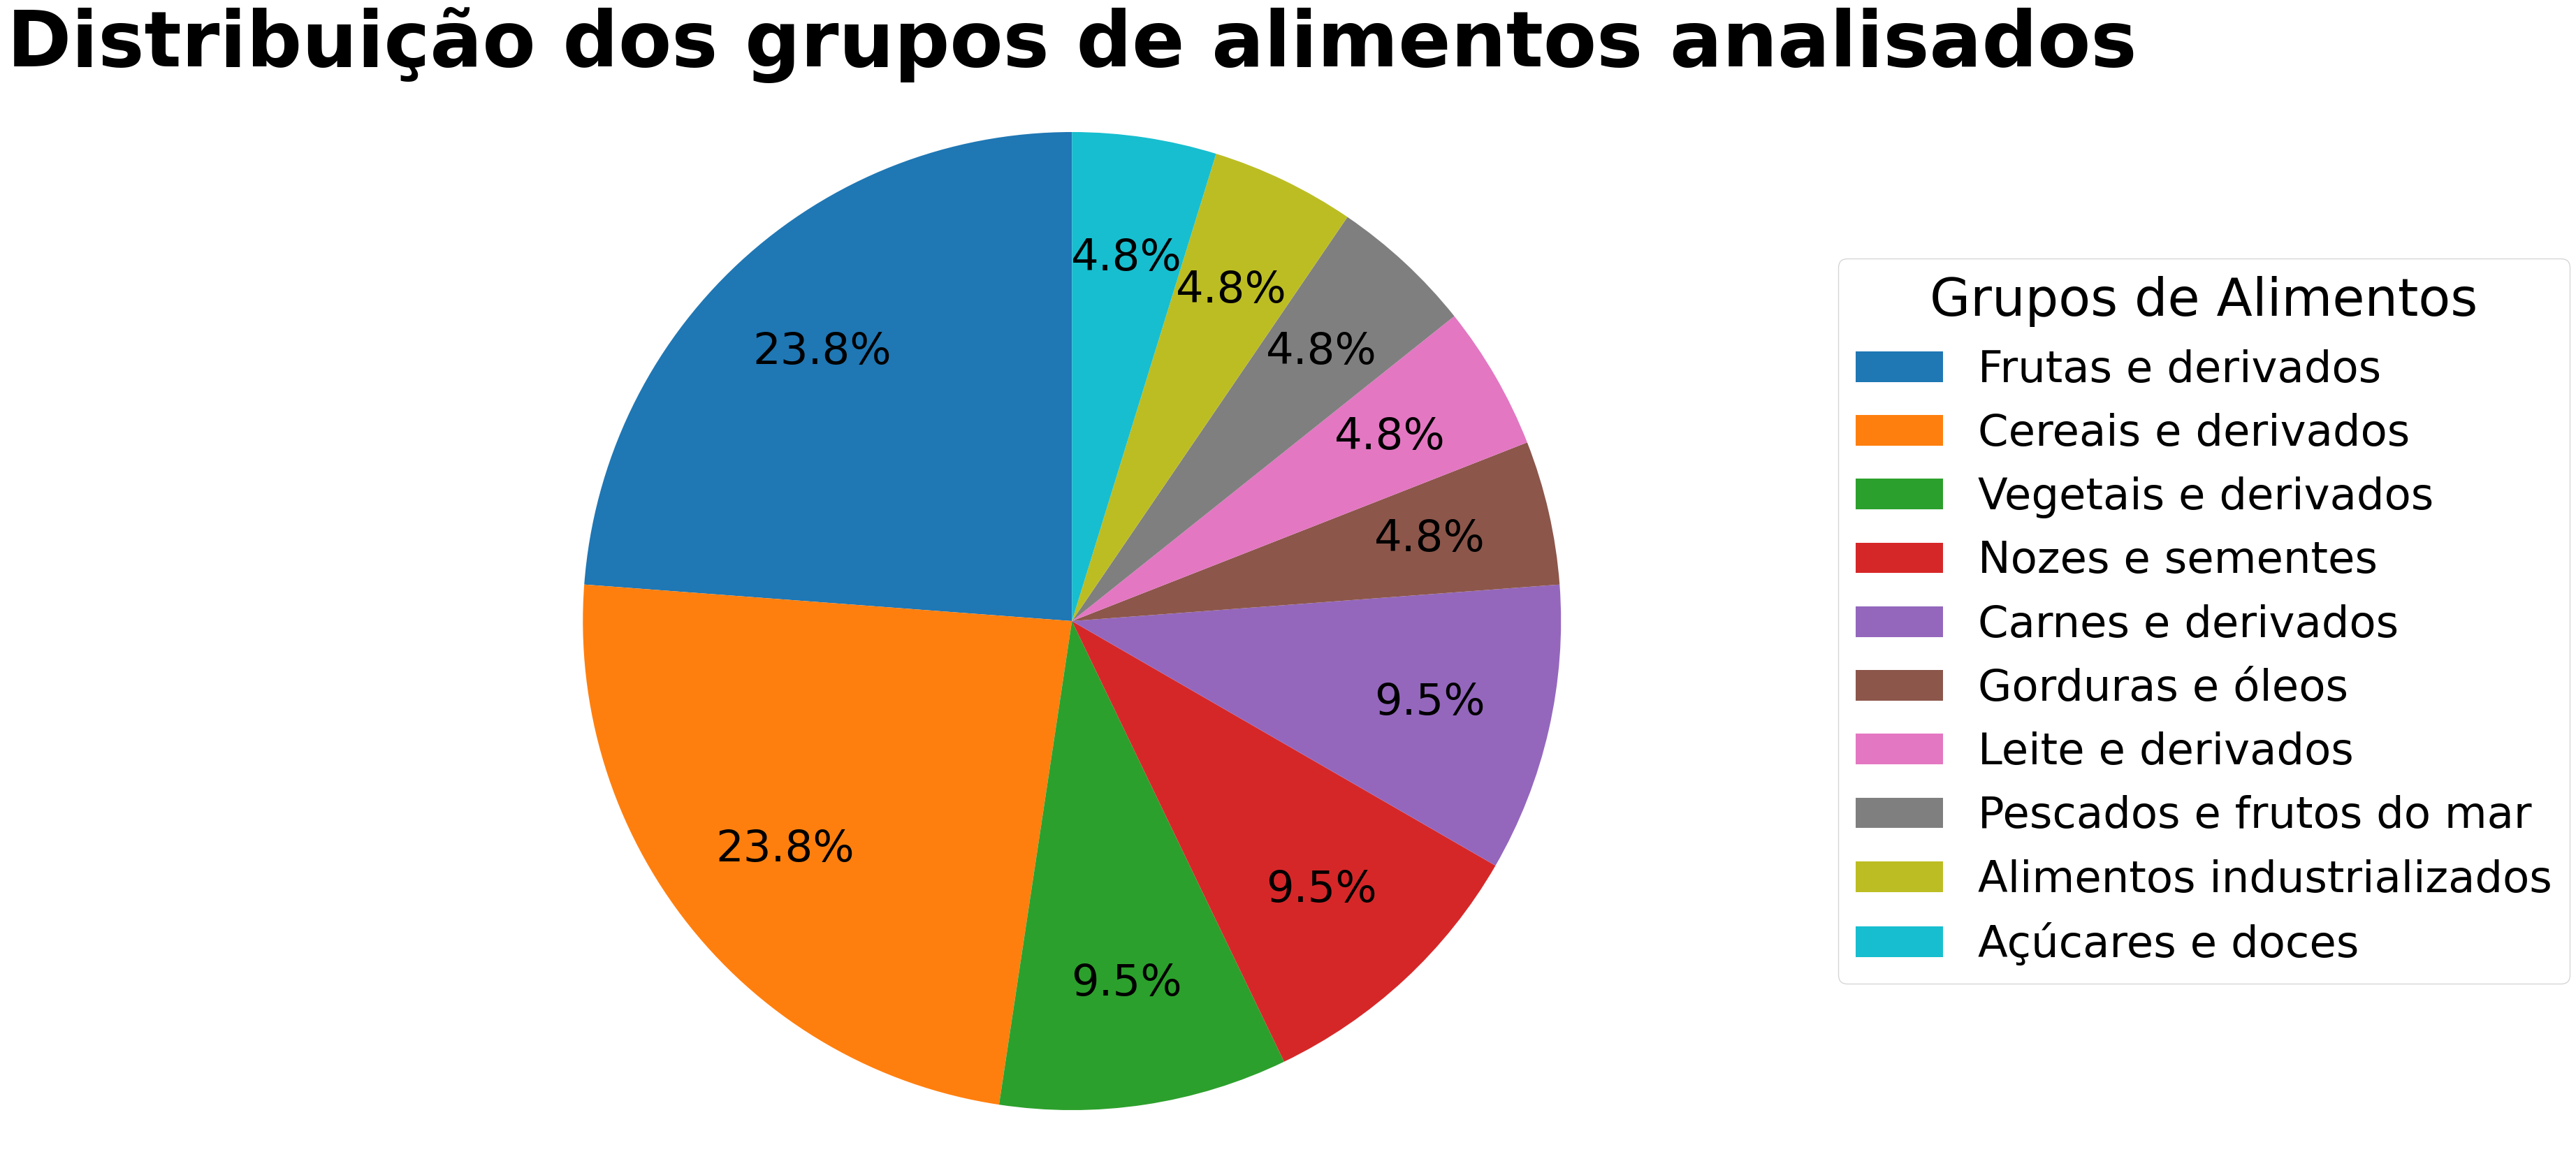

In [37]:
import matplotlib.pyplot as plt

# Count the occurrences of each food group
food_group_counts = df['Grupo de alimento'].value_counts()

# Create the pie chart
plt.figure(figsize=(25, 20)) # Increased figure size to accommodate larger pie and text
plt.pie(food_group_counts, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 45}, radius=1.2, pctdistance=0.75) # Adjusted pctdistance to 1.25x default
plt.title('Distribuição dos grupos de alimentos analisados', fontsize=80, fontweight='bold') # Title font size remains the same
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.legend(food_group_counts.index, title="Grupos de Alimentos", loc="center left", bbox_to_anchor=(1.05, 0, 0.5, 1), prop={'size': 45}, title_fontsize=54) # Legend font sizes remain the same, bbox_to_anchor might need further adjustment if legend is cut off
plt.show()

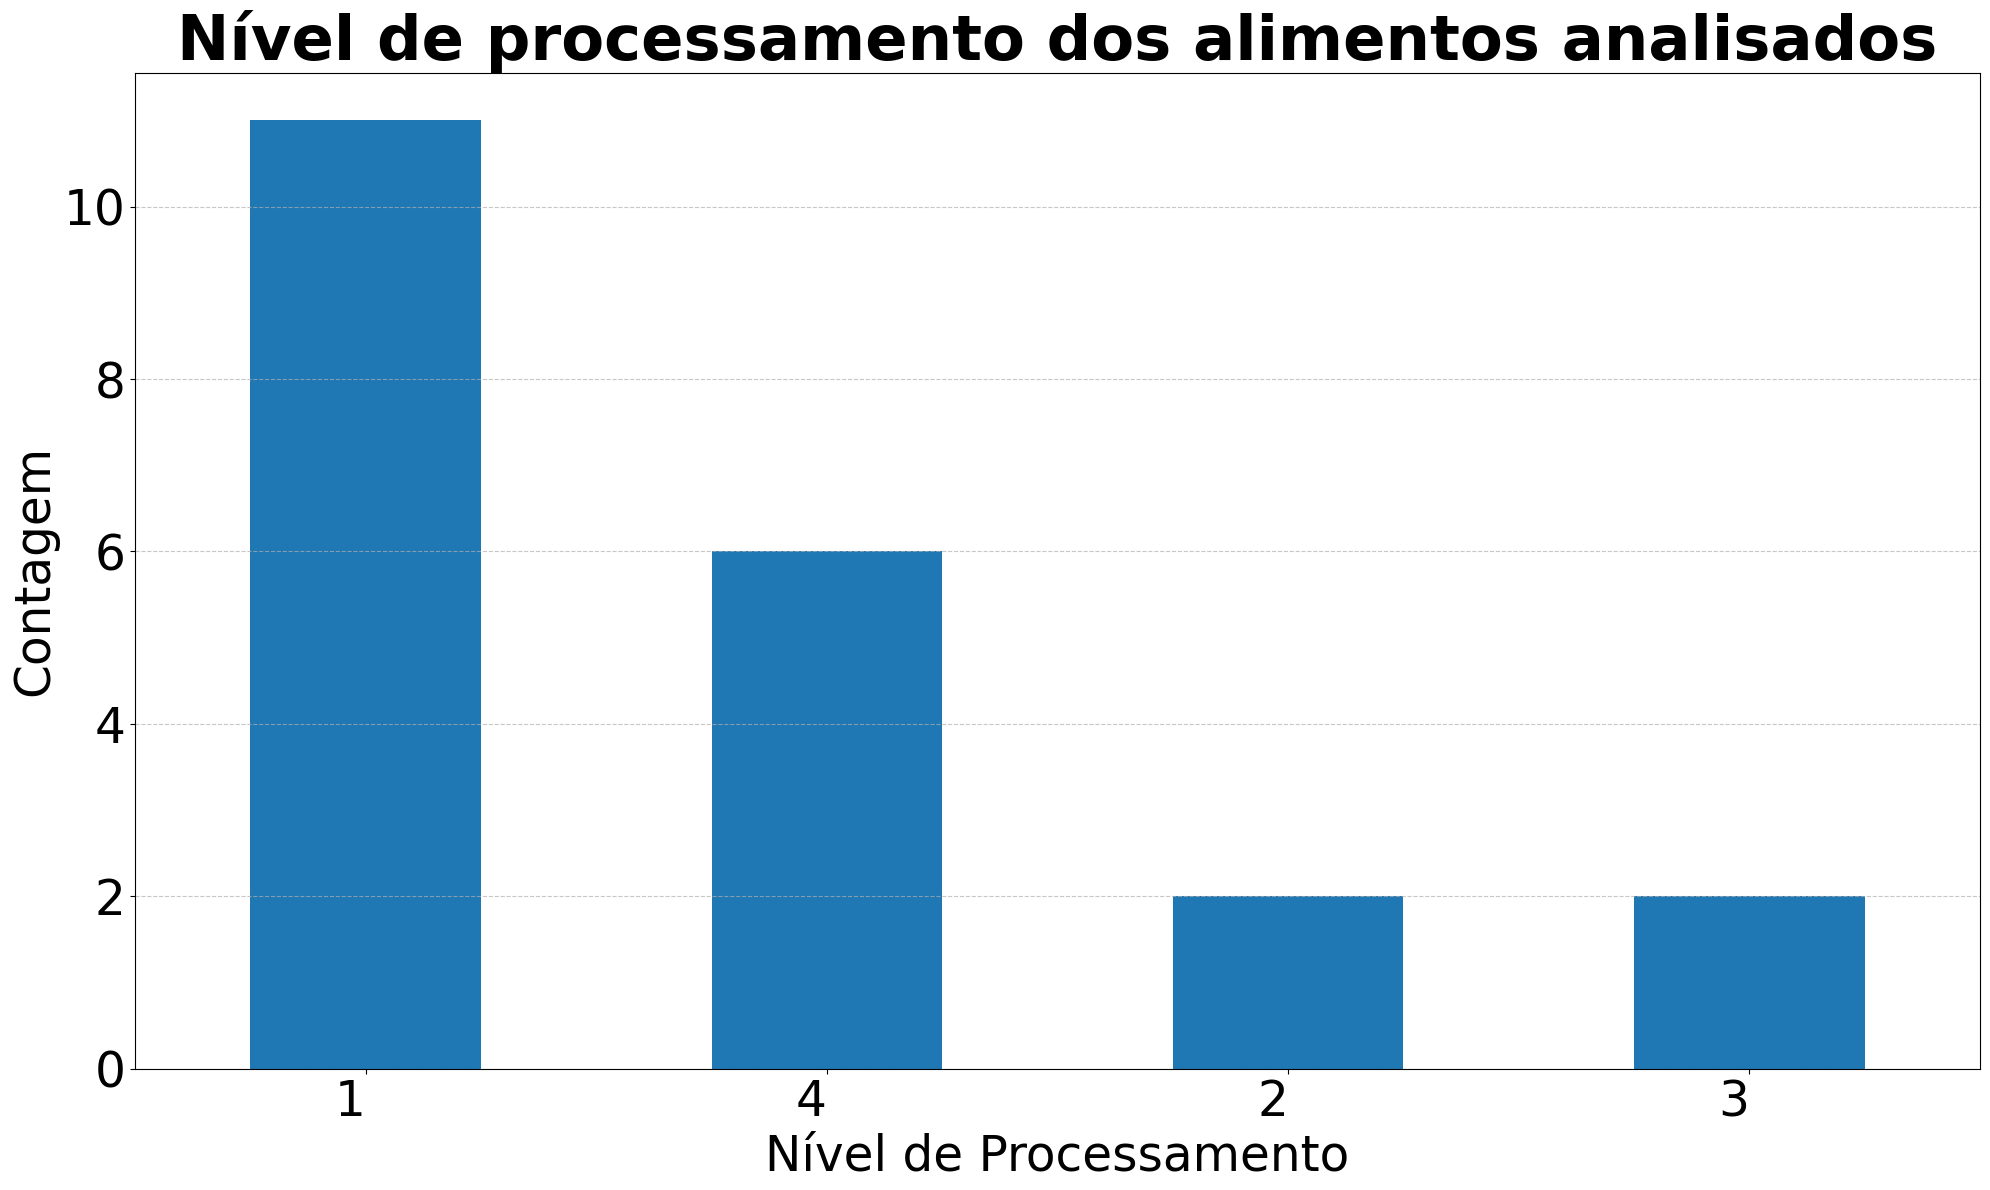

In [39]:
import matplotlib.pyplot as plt

# Count the occurrences of each processing level
processing_level_counts = df['Nível de processamento (1 menos processado, 4 mais processado)'].value_counts()

# Create the bar chart
plt.figure(figsize=(20, 12)) # Adjust figure size for better readability
processing_level_counts.plot(kind='bar')

plt.title('Nível de processamento dos alimentos analisados', fontsize=45, fontweight='bold')
plt.xlabel('Nível de Processamento', fontsize=35) # Adjusted font size
plt.ylabel('Contagem', fontsize=35) # Adjusted font size
plt.xticks(rotation=0, ha='right', fontsize=35) # Adjusted font size for x-axis labels
plt.yticks(fontsize=35) # Adjusted font size for y-axis labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

Legenda:
*   1 - minimamente processado
*   2 - ingredientes culinários processados
*   3 - alimentos processados
*   4 - alimentos ultraprocessados

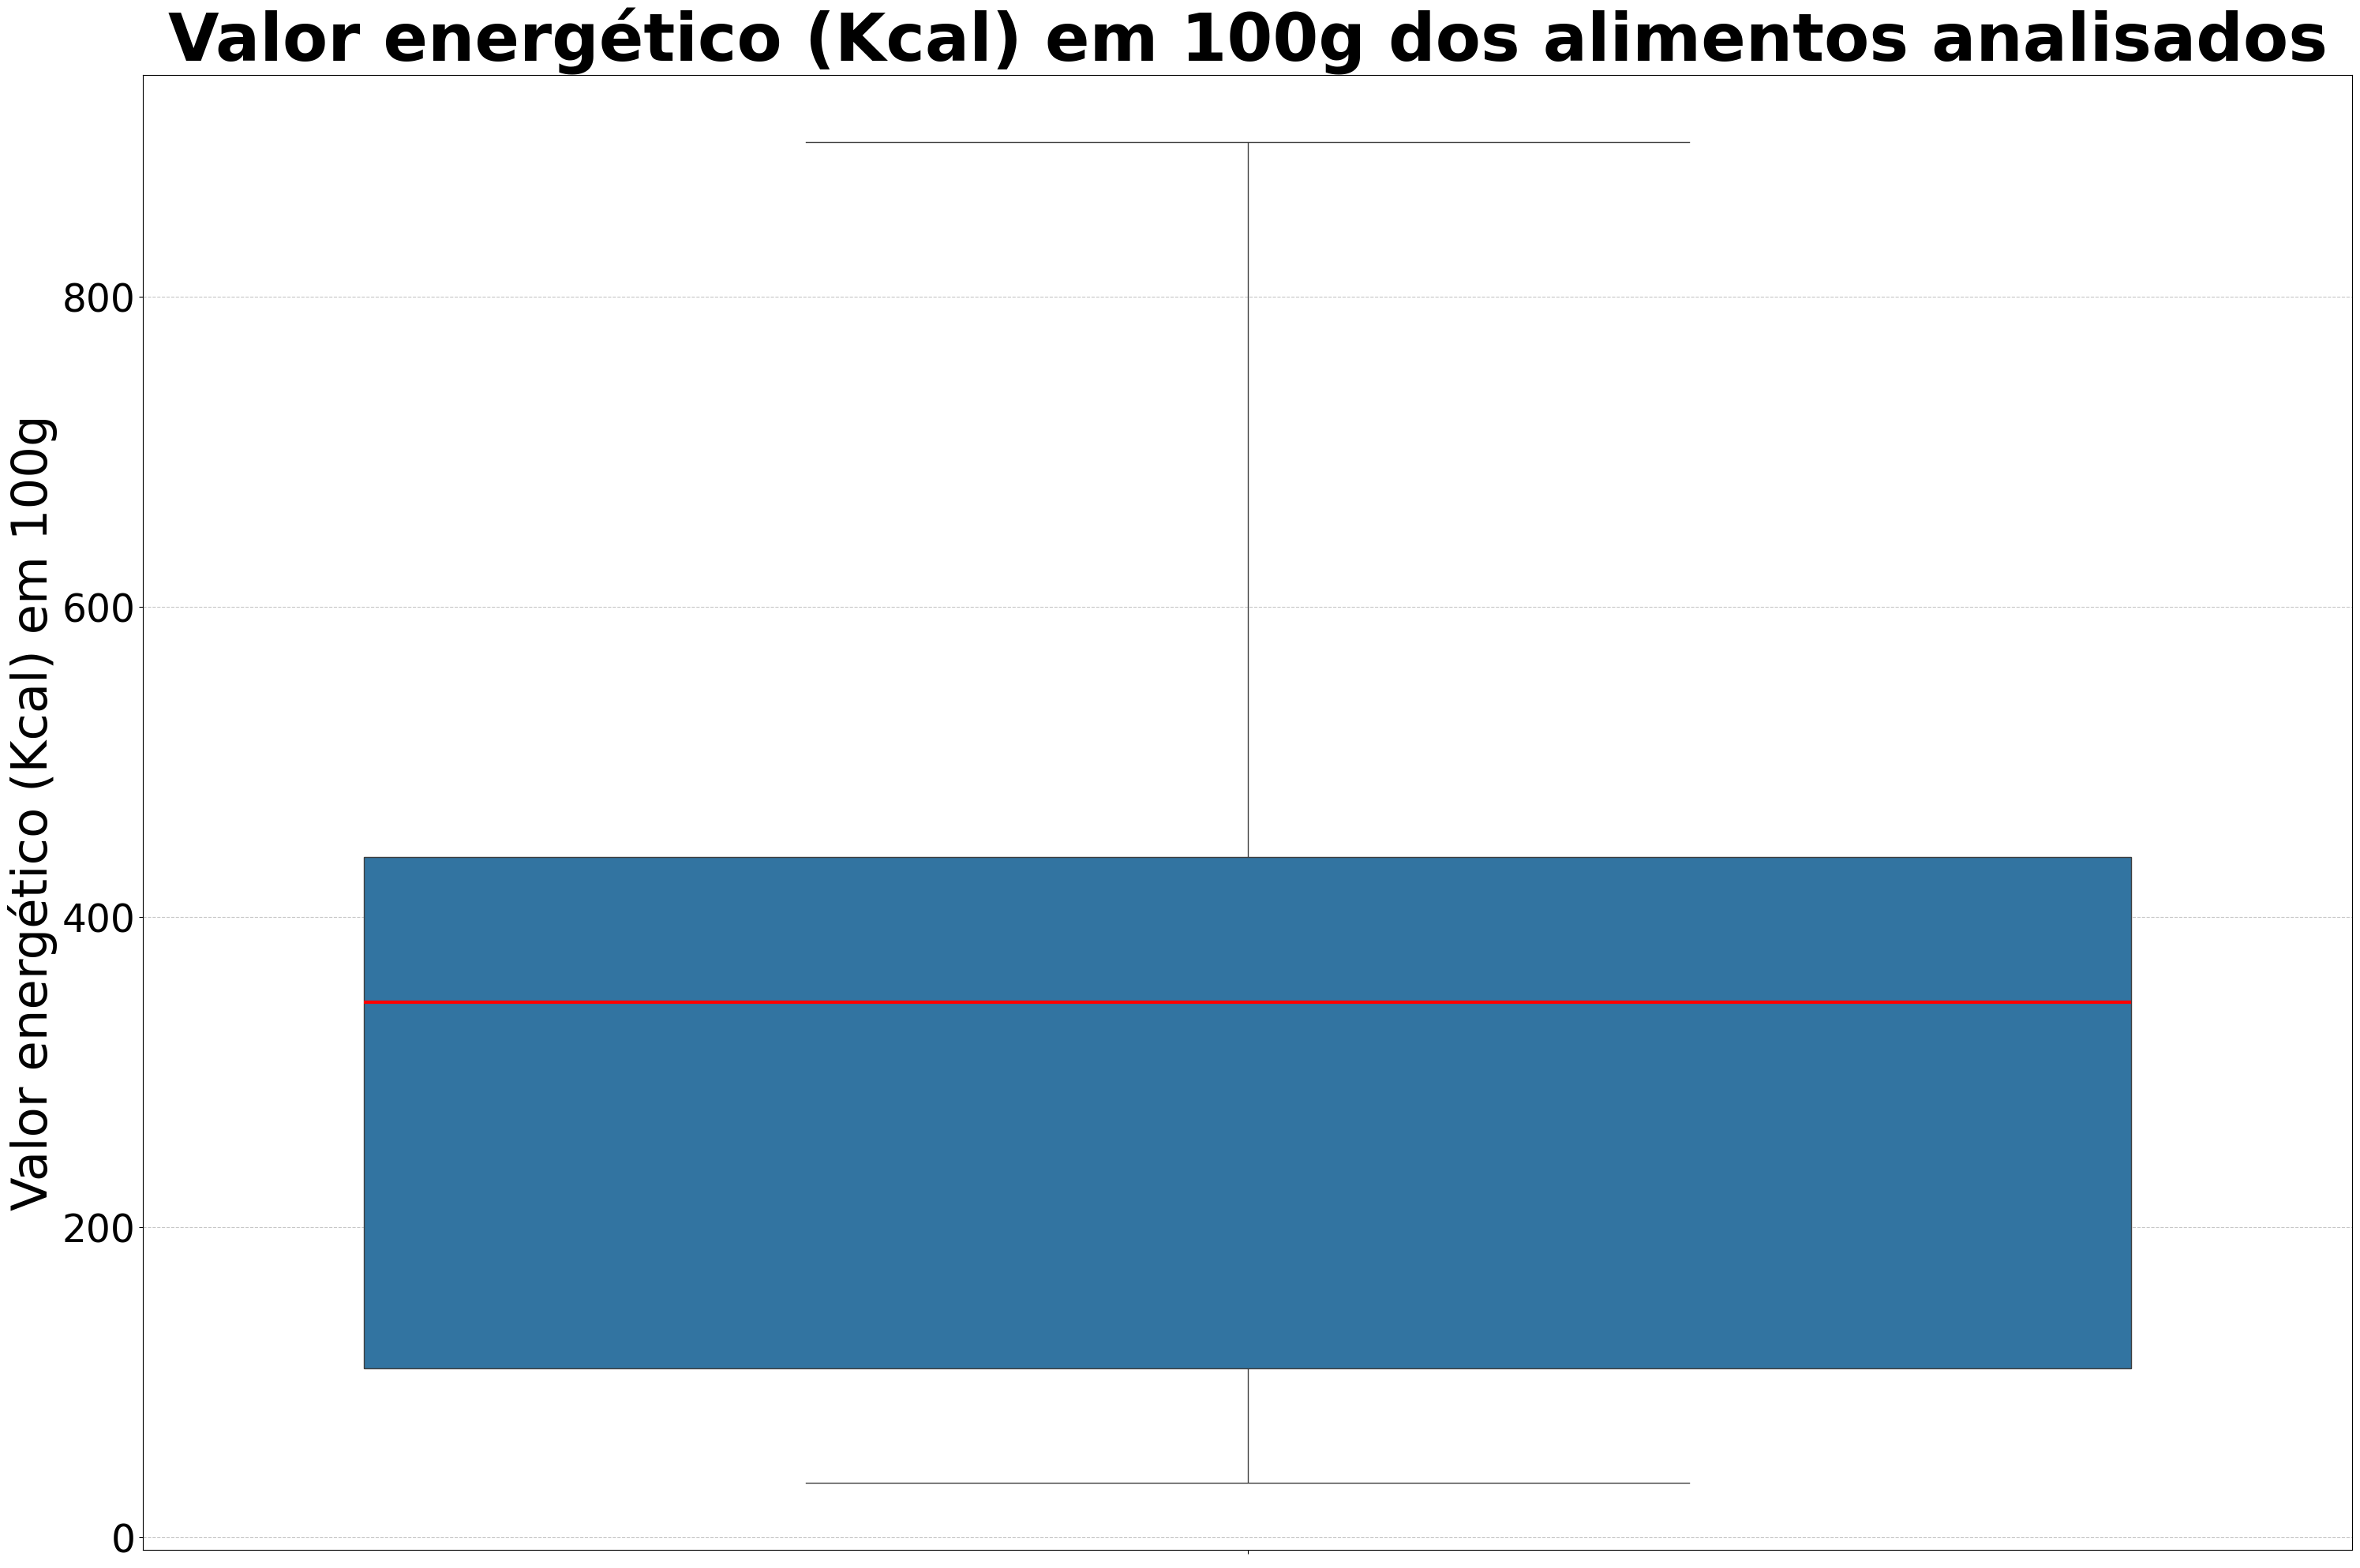

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the boxplot
plt.figure(figsize=(30, 20)) # Adjust figure size as needed (dobrado para 2x)
sns.boxplot(y=df['Valor energético (Kcal) em 100g'],
            medianprops={'color': 'red', 'linewidth': 3},
            flierprops={'marker': 'o', 'markerfacecolor': 'purple', 'markersize': 10})

plt.title('Valor energético (Kcal) em 100g dos alimentos analisados', fontsize=60, fontweight='bold')
plt.ylabel('Valor energético (Kcal) em 100g', fontsize=45)
plt.yticks(fontsize=35) # Adjust tick label font size
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [44]:
import pandas as pd

# Calculate the statistics
mean_val = df['Valor energético (Kcal) em 100g'].mean()
median_val = df['Valor energético (Kcal) em 100g'].median()
# mode_val = df['Valor energético (Kcal) em 100g'].mode().tolist() # Moda removida
quartile_1 = df['Valor energético (Kcal) em 100g'].quantile(0.25)
quartile_2 = df['Valor energético (Kcal) em 100g'].quantile(0.50) # This is also the median
quartile_3 = df['Valor energético (Kcal) em 100g'].quantile(0.75)

# Create a DataFrame to display the statistics as a table (Moda removida)
stats_df = pd.DataFrame({
    'Estatística': ['Média', 'Mediana', '1º Quartil', '2º Quartil', '3º Quartil'],
    'Valor': [mean_val, median_val, quartile_1, quartile_2, quartile_3]
})

# Format the 'Valor' column to 5 significant figures
stats_df['Valor'] = stats_df['Valor'].apply(lambda x: f'{x:.5g}')

# Display the table
display(stats_df)

,Estatística,Valor
0,Média,329.05
1,Mediana,345
2,1º Quartil,109
3,2º Quartil,345
4,3º Quartil,439


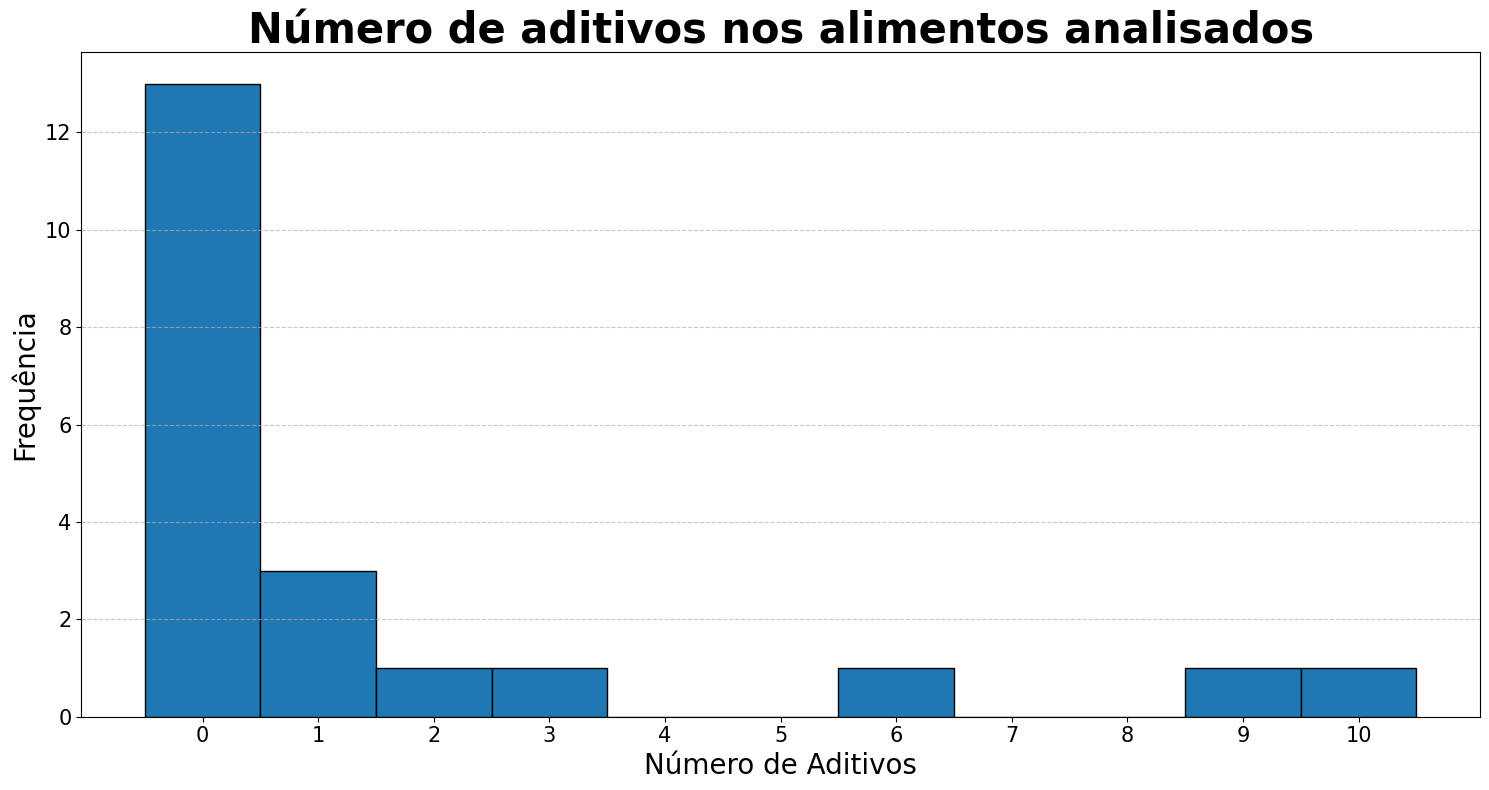

In [49]:
import matplotlib.pyplot as plt

# Create the histogram
plt.figure(figsize=(15, 8))
plt.hist(df['Número de aditivos'], bins=range(int(df['Número de aditivos'].max()) + 2), edgecolor='black', align='left')

plt.title('Número de aditivos nos alimentos analisados', fontsize=30, fontweight='bold')
plt.xlabel('Número de Aditivos', fontsize=20)
plt.ylabel('Frequência', fontsize=20)
plt.xticks(range(11), fontsize=15) # Ajusta os ticks para incluir 0 a 10
plt.yticks(fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Aditivos alimentares são substâncias adicionadas de forma intencional aos alimentos sem o propósito de nutrir. O objetivo é modificar características físicas, químicas, biológicas ou sensoriais, como melhorar a conservação, a cor, o sabor ou a textura de produtos industrializados.

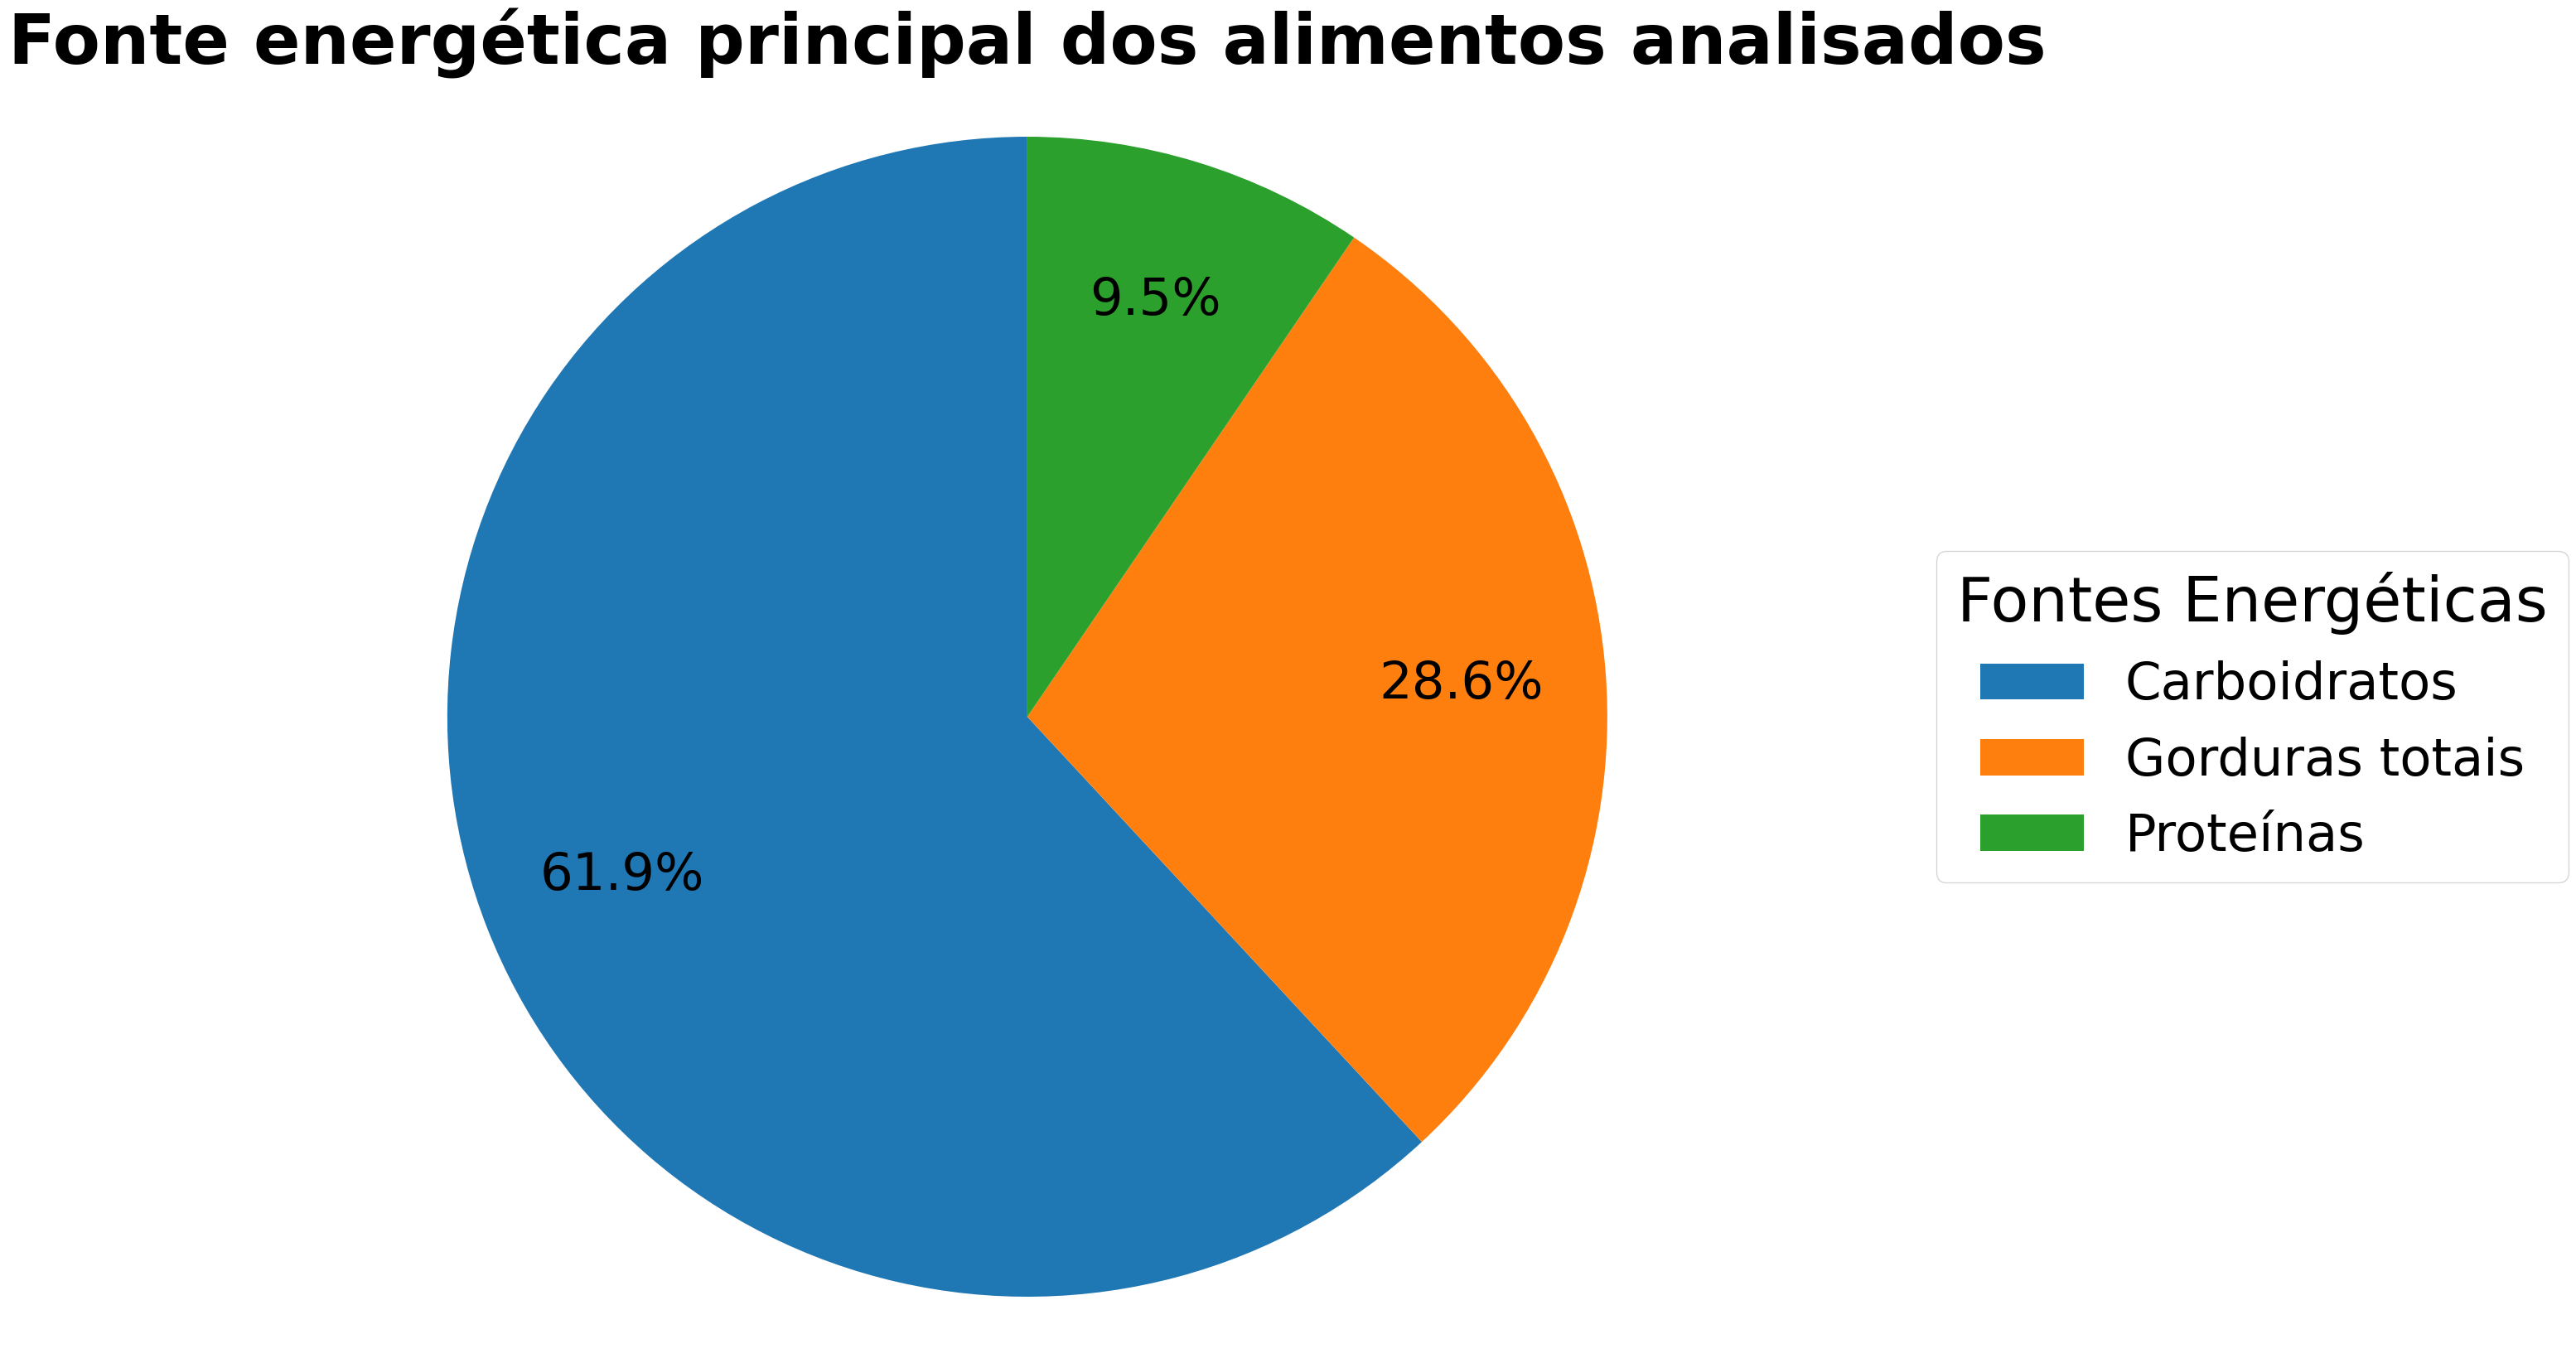

In [50]:
import matplotlib.pyplot as plt

# Count the occurrences of each main energy source
energy_source_counts = df['Valor energético proveniente principalmente de:'].value_counts()

# Create the pie chart
plt.figure(figsize=(25, 20))
plt.pie(energy_source_counts, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 45}, radius=1.2, pctdistance=0.75)
plt.title('Fonte energética principal dos alimentos analisados', fontsize=60, fontweight='bold')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.legend(energy_source_counts.index, title="Fontes Energéticas", loc="center left", bbox_to_anchor=(1.05, 0, 0.5, 1), prop={'size': 45}, title_fontsize=54)
plt.show()


*   Carboidratos e proteínas fornecem aproximadamente 4 Kcal/g
*   Gorduras fornecem aproximadamente 9 Kcal/g

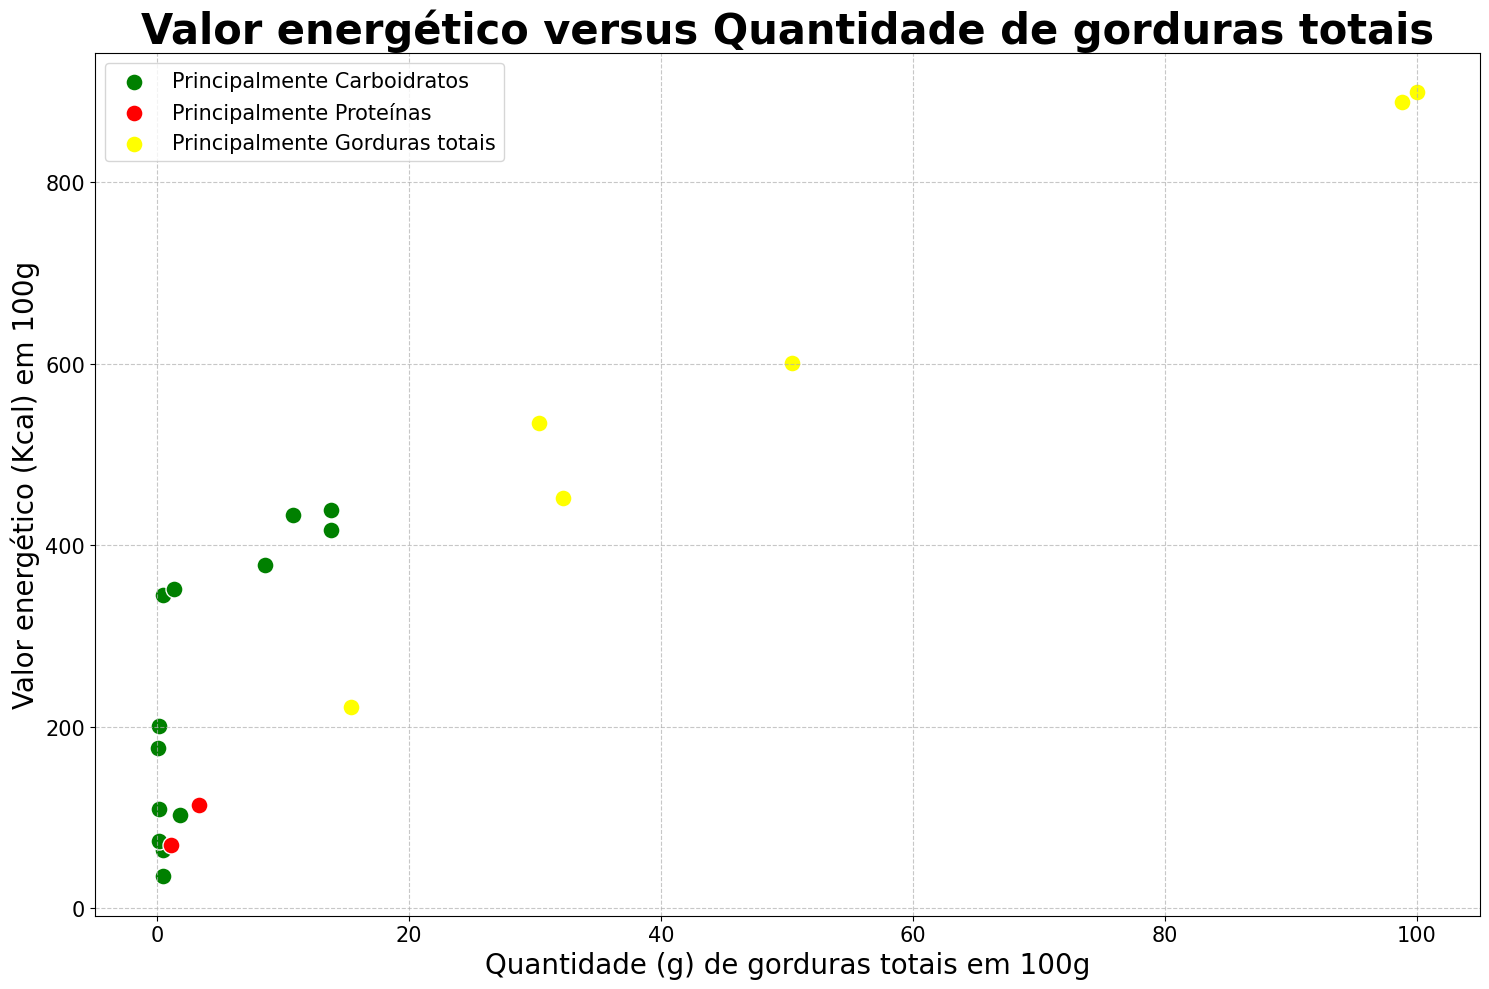


Regressão Linear e Correlação de Pearson:


,Métrica,Valor
0,Coeficiente de Inclinação (Slope),7.5919
1,Intercepto,190.3069
2,Coeficiente de Correlação de Pearson (r),0.8984
3,P-valor,0.0000
4,Erro Padrão,0.8515


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import pandas as pd # Ensure pandas is imported

plt.figure(figsize=(15, 10))

# Filter data for each energy source
carb_df = df[df['Valor energético proveniente principalmente de:'] == 'Carboidratos']
protein_df = df[df['Valor energético proveniente principalmente de:'] == 'Proteínas']
gordura_total_df = df[df['Valor energético proveniente principalmente de:'] == 'Gorduras totais']

# Plot Carboidratos in green
sns.scatterplot(
    data=carb_df,
    x='Quantidade (g) de gorduras totais em 100g',
    y='Valor energético (Kcal) em 100g',
    color='green',
    s=150, # Size of points
    label='Principalmente Carboidratos'
)

# Plot Proteínas in red
sns.scatterplot(
    data=protein_df,
    x='Quantidade (g) de gorduras totais em 100g',
    y='Valor energético (Kcal) em 100g',
    color='red',
    s=150, # Size of points
    label='Principalmente Proteínas'
)

# Plot Gorduras totais in yellow
sns.scatterplot(
    data=gordura_total_df,
    x='Quantidade (g) de gorduras totais em 100g',
    y='Valor energético (Kcal) em 100g',
    color='yellow',
    s=150, # Size of points - Adjusted to match other points
    marker='o', # Marker style for highlighted points
    label='Principalmente Gorduras totais'
)

plt.title('Valor energético versus Quantidade de gorduras totais', fontsize=30, fontweight='bold')
plt.xlabel('Quantidade (g) de gorduras totais em 100g', fontsize=20)
plt.ylabel('Valor energético (Kcal) em 100g', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Perform linear regression
x = df['Quantidade (g) de gorduras totais em 100g']
y = df['Valor energético (Kcal) em 100g']
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Create a table for the results
regression_results = pd.DataFrame({
    'Métrica': ['Coeficiente de Inclinação (Slope)', 'Intercepto', 'Coeficiente de Correlação de Pearson (r)', 'P-valor', 'Erro Padrão'],
    'Valor': [f'{slope:.4f}', f'{intercept:.4f}', f'{r_value:.4f}', f'{p_value:.4f}', f'{std_err:.4f}']
})

print('\nRegressão Linear e Correlação de Pearson:')
display(regression_results)

### Interpretação dos Resultados da Regressão Linear e Correlação de Pearson:

*   **Coeficiente de Inclinação (Slope):** Indica o quanto a variável dependente ('Valor energético') muda para cada unidade de aumento na variável independente ('Quantidade de gorduras totais'). Um valor de `7.5919` significa que, em média, para cada 1 grama adicional de gordura total por 100g de alimento, o valor energético aumenta em aproximadamente 7.59 Kcal.

*   **Intercepto:** Representa o valor esperado da variável dependente ('Valor energético') quando a variável independente ('Quantidade de gorduras totais') é zero. Um intercepto de `190.3069` sugere que um alimento sem gorduras totais teria um valor energético estimado de cerca de 190.31 Kcal por 100g.

*   **Coeficiente de Correlação de Pearson (r):** Mede a força e a direção da relação linear entre as duas variáveis. O valor `0.8984` indica uma forte correlação positiva, ou seja, à medida que a quantidade de gorduras totais aumenta, o valor energético também tende a aumentar significativamente. O valor 'P-valor' (`0.0000`) indica que a correlação observada é estatisticamente significativa.